In [2]:
import torch
import matplotlib.pyplot as plt

In [3]:
words = open('D:\\NN Andrej Karpathy\\NN andrej karpathy\\names.txt', 'r').read().splitlines()

In [ ]:
# Create a list of all unique characters in the dataset

list(set(''.join(words)))
characters = sorted(list(set(''.join(words))))


In [ ]:
# Maps characters to integers and vice versa

alphabet_to_index = {s:i+1 for i,s in enumerate(characters)}
alphabet_to_index['.'] = 0
index_to_alphabet = {i:s for s,i in alphabet_to_index.items()}
    

In [6]:
# Create a 27x27 matrix to count the occurrences of character pairs

N = torch.zeros((27,27), dtype=torch.int32)
for w in words:
    characters = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(characters, characters[1:]):
        index1 = alphabet_to_index[ch1]
        index2 = alphabet_to_index[ch2]
        N[index1,index2] += 1 

        

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

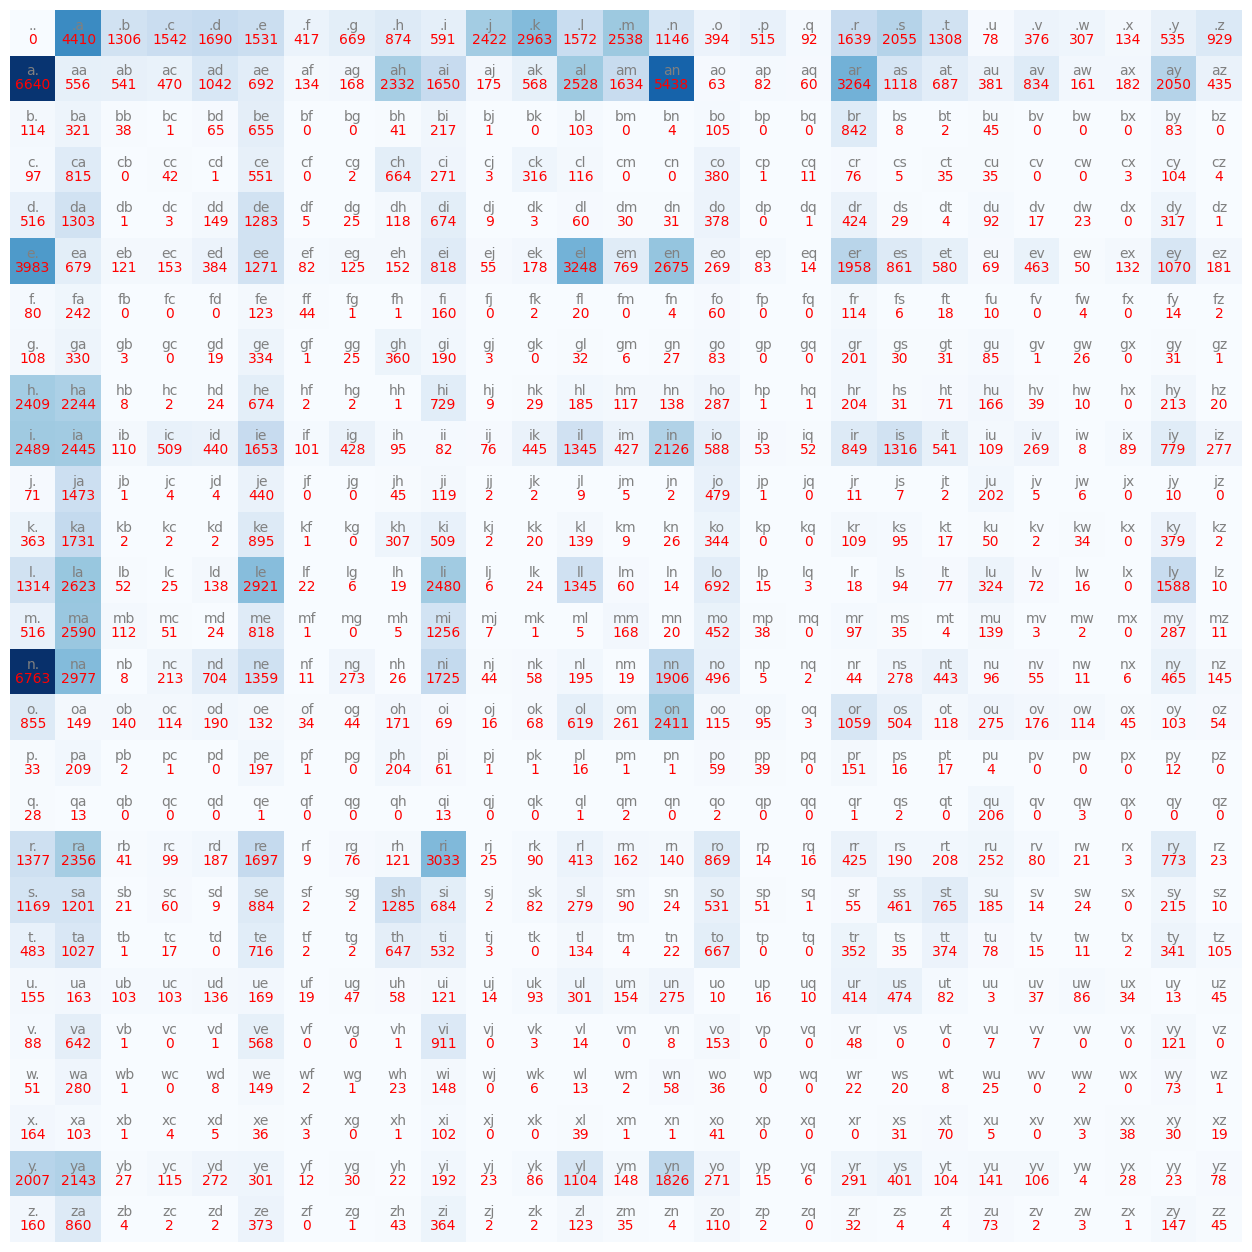

In [7]:
# Visualize the bigram counts

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = index_to_alphabet[i]+index_to_alphabet[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i,j].item(), ha='center', va='top', color='red')
plt.axis("off")

In [8]:
# Convert counts to probabilities row by row

Probs = N.float()
Prob_per_row = Probs/Probs.sum(1, keepdim=True) 

In [9]:
# Generate names from the bigram model

g = torch.Generator().manual_seed(214748367)

for i in range(27):
    out = []
    ix = 0
    while True:
        p = Prob_per_row[ix]
        ix = torch.multinomial(p, num_samples=1,replacement=True, generator=g).item()
        out.append(index_to_alphabet[ix])
        if ix == 0:
            break
    print(''.join(out))

ah.
blly.
guacatoue.
j.
aran.
todvenaya.
m.
skun.
ir.
k.
m.
alyonel.
donsarourr.
i.
deprgte.
atuw.
gi.
jama.
evyddeean.
o.
moin.
a.
ckenailen.
stha.
rrado.
tie.
gweolldheralyar.


# Loss Function

In [10]:
# Evaluate the log-likelihood and negative log-likelihood of the training data under the model (loss function)

log_likelihood = 0.0
n = 0

for w in words: 
    characters = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(characters, characters[1:]):
        index1 = alphabet_to_index[ch1]
        index2 = alphabet_to_index[ch2]
        prob = Prob_per_row[index1,index2]
        log_likelihood += torch.log(prob)
        n += 1

print("log likelihood: ", log_likelihood.item())
print("Negative log-likelihood: ", -log_likelihood.item())
print("Average Negative Log-Likelihood: ", (-log_likelihood/n).item())

log likelihood:  -559891.75
Negative log-likelihood:  559891.75
Average Negative Log-Likelihood:  2.454094171524048
